In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cài đặt thư viện

In [ ]:
import os
import torch
import torch.nn as nn
import math
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights


from collections import Counter
from torch.utils.data import WeightedRandomSampler
from tqdm import tqdm

# Data Augmentation

In [ ]:
def get_datasets():
    train_transform = transforms.Compose([
      transforms.Resize((224,224)),
      transforms.RandomHorizontalFlip(),
      transforms.RandomRotation(5),
      transforms.RandomAffine(
          degrees=0,
          translate=(0.05,0.05)
      ),
      transforms.ToTensor(),
      transforms.Normalize(
          [0.485,0.456,0.406],
          [0.229,0.224,0.225]
      )
  ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    dest_path = '/content/drive/MyDrive/spikingjelly/'

    trainset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Training'),
        transform=train_transform
    )
    valset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Testing'),
        transform=val_transform
    )
    testset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Testing'),
        transform=val_transform
    )

    return trainset, valset, testset

# Tổng hợp data và áp dụng Sample Weights

In [ ]:
trainset, valset, testset = get_datasets()

print(f"\n✓ Train dataset: {len(trainset)} images, {len(trainset.classes)} classes")
print(f"✓ Validation dataset: {len(valset)} images, {len(valset.classes)} classes")
print(f"✓ Classes: {trainset.classes}")

labels = [label for _, label in trainset.samples]

class_counts = Counter(labels)

print("Class counts:", class_counts)

sample_weights = []

for _, label in trainset.samples:

    sample_weights.append(
        1.0 / class_counts[label]
    )

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


✓ Train dataset: 5600 images, 4 classes
✓ Validation dataset: 1600 images, 4 classes
✓ Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class counts: Counter({0: 1400, 1: 1400, 2: 1400, 3: 1400})


In [ ]:
trainloader = torch.utils.data.DataLoader(
        trainset,
        batch_size=16,
        shuffle=False,
        sampler=sampler,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        drop_last=True
    )

valloader = torch.utils.data.DataLoader(
        valset,
        batch_size=16,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        drop_last=True
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Triển khai model ViT-B16

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)

in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, 4)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.5)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)

# Train model

In [ ]:
best_acc = 0
patience = 6
counter = 0

for epoch in range(50):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_loss = 0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}")

    for imgs, labels in train_pbar:

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        total_loss += loss.item()

        train_pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{train_correct/train_total:.4f}"
        )

    train_loss = total_loss / len(trainloader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    print("Starting validation...")

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():

        for imgs, labels in val_pbar:

            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)

            if outputs.dim() == 3:
                outputs = outputs.mean(0)

            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loss += loss.item()

    val_loss /= len(valloader)
    val_acc = correct / total

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # =========================
    # LR Scheduler
    # =========================
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'best_acc': best_acc
        }, "/content/drive/MyDrive/spikingjelly/best_model_ViT16_brain_tumor.pth")

        print("Saved best model")

    else:

        counter += 1

        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    # print learning rate
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])

Epoch 1:   0%|          | 0/350 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1: 100%|██████████| 350/350 [11:46<00:00,  2.02s/it, acc=0.8995, loss=1.0892]


Starting validation...


Validation: 100%|██████████| 100/100 [04:57<00:00,  2.98s/it]


Epoch 1 | Train Loss 1.1423 | Train Acc 0.8995 | Val Loss 1.1391 | Val Acc 0.9106
Saved best model
LR: 0.0001


Epoch 2: 100%|██████████| 350/350 [05:00<00:00,  1.17it/s, acc=0.9459, loss=1.0887]


...

Epoch 28 | Train Loss 1.0745 | Train Acc 0.9980 | Val Loss 1.1112 | Val Acc 0.9500
EarlyStopping counter: 5/6
LR: 1.25e-05


Epoch 29: 100%|██████████| 350/350 [03:26<00:00,  1.70it/s, acc=0.9973, loss=1.0736]


Starting validation...


Validation: 100%|██████████| 100/100 [00:19<00:00,  5.01it/s]

Epoch 29 | Train Loss 1.0753 | Train Acc 0.9973 | Val Loss 1.1126 | Val Acc 0.9494
EarlyStopping counter: 6/6
Early stopping triggered.


# Đánh giá metrics của model


Running evaluation...


100%|██████████| 100/100 [00:20<00:00,  4.94it/s, acc=0.952]



===== RESULTS =====
Accuracy       : 0.9519
Loss           : 0.5505
F1 (macro)     : 0.9507
F1 (weighted)  : 0.9507

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.83      0.90       400
  meningioma       0.91      0.98      0.95       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



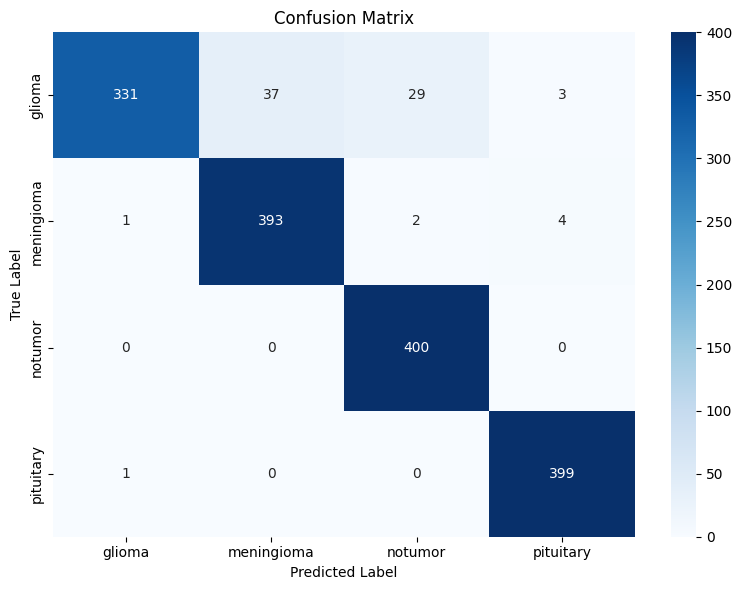

In [ ]:
checkpoint = torch.load(
    "/content/drive/MyDrive/spikingjelly/best_model_ViT16_brain_tumor.pth",
    map_location=device
)
model.load_state_dict(checkpoint["model"])
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True
)

model.eval()
criterion = nn.CrossEntropyLoss()

correct, total = 0, 0
total_loss = 0

all_preds = []
all_labels = []

print("\nRunning evaluation...")
with torch.no_grad():
    pbar = tqdm(testloader)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        preds = outputs.argmax(1)

        total_loss += loss.item()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix(acc=correct / total)

acc = correct / total
avg_loss = total_loss / len(testloader)

# F1 scores
f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("\n===== RESULTS =====")
print(f"Accuracy       : {acc:.4f}")
print(f"Loss           : {avg_loss:.4f}")
print(f"F1 (macro)     : {f1_macro:.4f}")
print(f"F1 (weighted)  : {f1_weighted:.4f}")

# Optional: per-class metrics
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=testset.classes))
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=testset.classes,
    yticklabels=testset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()